# Baseline Model: LightGBM

**Цель**: получить первый числовой бенчмарк RMSLE на val-сете (2017-08-01—2017-08-15).

## Self-check

| Вопрос | Ответ |
|--------|-------|
| **Leakage** | Обучаем строго на train (≤2017-07-31). Val/test не попадают в fit. |
| **Целевая переменная** | `log1p(sales)` → RMSE в log-пространстве ≡ RMSLE. |
| **NaN в лагах** | LightGBM обрабатывает NaN нативно — заполнять не нужно. |
| **Категориальные фичи** | Переданы явно в `categorical_feature` — LightGBM использует оптимальные сплиты. |
| **Воспроизводимость** | `seed=42` во всех операциях. |

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import lightgbm as lgb
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

processed_dir = os.path.join('..', 'data', 'processed')
artifacts_dir = os.path.join('..', 'artifacts')

train = pd.read_parquet(os.path.join(processed_dir, 'train_fe.parquet'))
val   = pd.read_parquet(os.path.join(processed_dir, 'val_fe.parquet'))
test  = pd.read_parquet(os.path.join(processed_dir, 'test_fe.parquet'))

print(f'Train: {train.shape} | Val: {val.shape} | Test: {test.shape}')
print(f'Train date range: {train["date"].min().date()} — {train["date"].max().date()}')
print(f'Val   date range: {val["date"].min().date()} — {val["date"].max().date()}')
print(f'Test  date range: {test["date"].min().date()} — {test["date"].max().date()}')

Train: (2981286, 32) | Val: (26730, 32) | Test: (28512, 32)
Train date range: 2013-01-01 — 2017-07-31
Val   date range: 2017-08-01 — 2017-08-15
Test  date range: 2017-08-16 — 2017-08-31


## 1. Feature Preparation

In [2]:
# Исключаем идентификаторы и таргет из матрицы признаков
DROP_COLS = ['date', 'sales']

FEATURE_COLS = [c for c in train.columns if c not in DROP_COLS]

# LightGBM принимает категориальные признаки как int
# Передаём явно — это даёт оптимальные сплиты по многим категориям
CAT_FEATURES = ['store_nbr', 'family', 'city', 'state', 'type', 'cluster',
                 'day_of_week', 'month', 'quarter']

X_train = train[FEATURE_COLS]
y_train = train['sales']

X_val = val[FEATURE_COLS]
y_val = val['sales']

X_test = test[FEATURE_COLS]

# log1p-трансформация: RMSE(log1p(pred), log1p(actual)) == RMSLE(pred, actual)
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)

print(f'Features: {len(FEATURE_COLS)}')
print(f'Categorical: {CAT_FEATURES}')
print(f'y_train_log — mean: {y_train_log.mean():.3f}, std: {y_train_log.std():.3f}')
print(f'Zeros in train: {(y_train == 0).mean():.1%}')

Features: 30
Categorical: ['store_nbr', 'family', 'city', 'state', 'type', 'cluster', 'day_of_week', 'month', 'quarter']
y_train_log — mean: 2.913, std: 2.696
Zeros in train: 31.6%


## 2. LightGBM Baseline

Параметры выбраны как разумный старт без тюнинга:
- `num_leaves=255` — достаточно глубокие деревья для захвата взаимодействий (store × family × сезон).
- `feature_fraction=0.8` + `bagging_fraction=0.8` — лёгкая регуляризация для уменьшения переобучения.
- `min_child_samples=50` — защита от мелких листьев на разреженных store×family.
- `n_estimators=2000` + `early_stopping_rounds=50` — останавливаемся по val RMSE.

In [4]:
params = {
    'objective':        'regression',
    'metric':           'rmse',
    'num_leaves':       255,
    'learning_rate':    0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'min_child_samples':50,
    'lambda_l1':        0.1,
    'lambda_l2':        0.1,
    'verbose':         -1,
    'seed':             SEED,
    'n_jobs':          -1,
}

dtrain = lgb.Dataset(
    X_train, label=y_train_log,
    categorical_feature=CAT_FEATURES,
    free_raw_data=False
)
dval = lgb.Dataset(
    X_val, label=y_val_log,
    reference=dtrain,
    free_raw_data=False
)

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100),
]

model = lgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    valid_sets=[dtrain, dval],
    valid_names=['train', 'val'],
    callbacks=callbacks,
)

print(f'\nBest iteration: {model.best_iteration}')
print(f'Best val RMSE (log space): {model.best_score["val"]["rmse"]:.4f}')

Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.376216	val's rmse: 0.384191
[200]	train's rmse: 0.355062	val's rmse: 0.378333
[300]	train's rmse: 0.347527	val's rmse: 0.376516
[400]	train's rmse: 0.342485	val's rmse: 0.375215
Early stopping, best iteration is:
[397]	train's rmse: 0.342618	val's rmse: 0.374905

Best iteration: 397
Best val RMSE (log space): 0.3749


## 3. Evaluation

In [5]:
def rmsle(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root Mean Squared Logarithmic Error."""
    y_pred = np.clip(y_pred, 0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))


val_pred_log = model.predict(X_val, num_iteration=model.best_iteration)
val_pred     = np.expm1(val_pred_log).clip(0)

score = rmsle(y_val.values, val_pred)
print(f'Val RMSLE: {score:.4f}')

# Breakdown по family (топ-5 худших)
val_results = val[['date', 'store_nbr', 'family', 'sales']].copy()
val_results['pred'] = val_pred

family_rmsle = (
    val_results.groupby('family')
    .apply(lambda g: rmsle(g['sales'].values, g['pred'].values))
    .rename('rmsle')
    .sort_values(ascending=False)
)

print('\nTop-10 worst families by RMSLE:')
print(family_rmsle.head(10).to_string())
print(f'\nBest family RMSLE: {family_rmsle.min():.4f} ({family_rmsle.idxmin()})')
print(f'Median family RMSLE: {family_rmsle.median():.4f}')

Val RMSLE: 0.3749

Top-10 worst families by RMSLE:
family
21    0.593960
31    0.549449
13    0.547669
6     0.527656
14    0.524194
23    0.503505
0     0.499492
32    0.476046
26    0.466126
19    0.461767

Best family RMSLE: 0.0785 (4)
Median family RMSLE: 0.3099


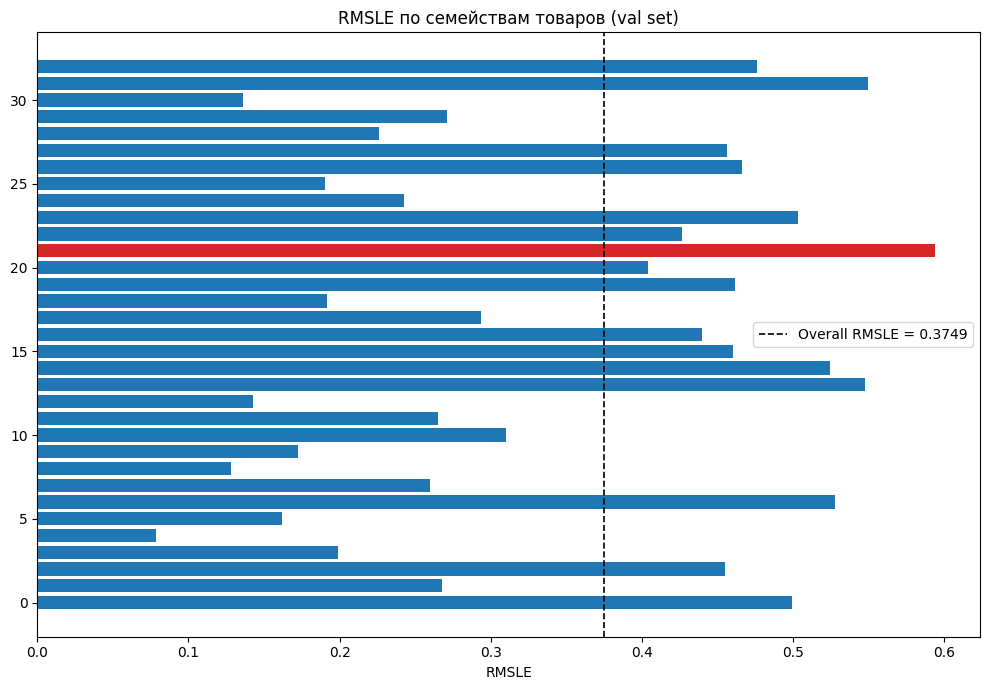

In [6]:
# Визуализация RMSLE по семействам товаров
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#d62728' if v > score * 1.5 else '#1f77b4' for v in family_rmsle.values]
bars = ax.barh(family_rmsle.index[::-1], family_rmsle.values[::-1], color=colors[::-1])
ax.axvline(score, color='black', linestyle='--', linewidth=1.2, label=f'Overall RMSLE = {score:.4f}')

ax.set_xlabel('RMSLE')
ax.set_title('RMSLE по семействам товаров (val set)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'family_rmsle.png'), dpi=120)
plt.show()

## 4. Feature Importance

In [7]:
importance = pd.Series(
    model.feature_importance(importance_type='gain'),
    index=FEATURE_COLS
).sort_values(ascending=False)

print('Top-20 features by gain:')
print(importance.head(20).to_string())

# Фичи с нулевым вкладом — кандидаты на удаление
zero_importance = importance[importance == 0]
if len(zero_importance):
    print(f'\n[!] Zero-importance features ({len(zero_importance)}): {list(zero_importance.index)}')
else:
    print('\n[OK] All features contribute.')

Top-20 features by gain:
rolling_mean_7             9.582980e+07
rolling_median_7           4.117139e+07
lag_7                      2.961825e+07
rolling_mean_14            2.926600e+06
lag_14                     9.789081e+05
day_of_month               9.128315e+05
family                     5.589525e+05
lag_28                     4.783775e+05
rolling_mean_30            2.720254e+05
day_of_week                2.558074e+05
lag_364                    2.480912e+05
week_of_year               2.439266e+05
onpromotion                2.104777e+05
oil_price                  2.085795e+05
store_nbr                  1.996189e+05
oil_ma_7                   1.753326e+05
days_to_next_holiday       1.553255e+05
is_weekend                 1.492744e+05
month                      1.301441e+05
days_since_last_holiday    1.034549e+05

[OK] All features contribute.


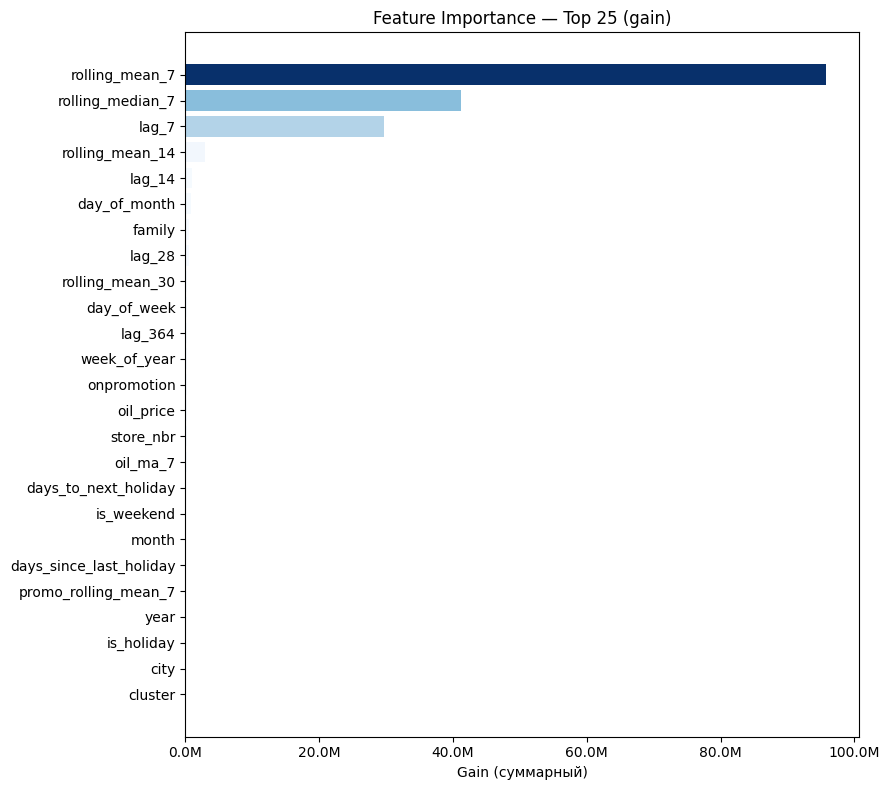

In [8]:
top_n = 25
top_imp = importance.head(top_n)

fig, ax = plt.subplots(figsize=(9, 8))
norm = plt.Normalize(top_imp.values.min(), top_imp.values.max())
colors = plt.cm.Blues(norm(top_imp.values[::-1]))

ax.barh(top_imp.index[::-1], top_imp.values[::-1], color=colors)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_xlabel('Gain (суммарный)')
ax.set_title(f'Feature Importance — Top {top_n} (gain)')
plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'feature_importance.png'), dpi=120)
plt.show()

## 5. Error Analysis

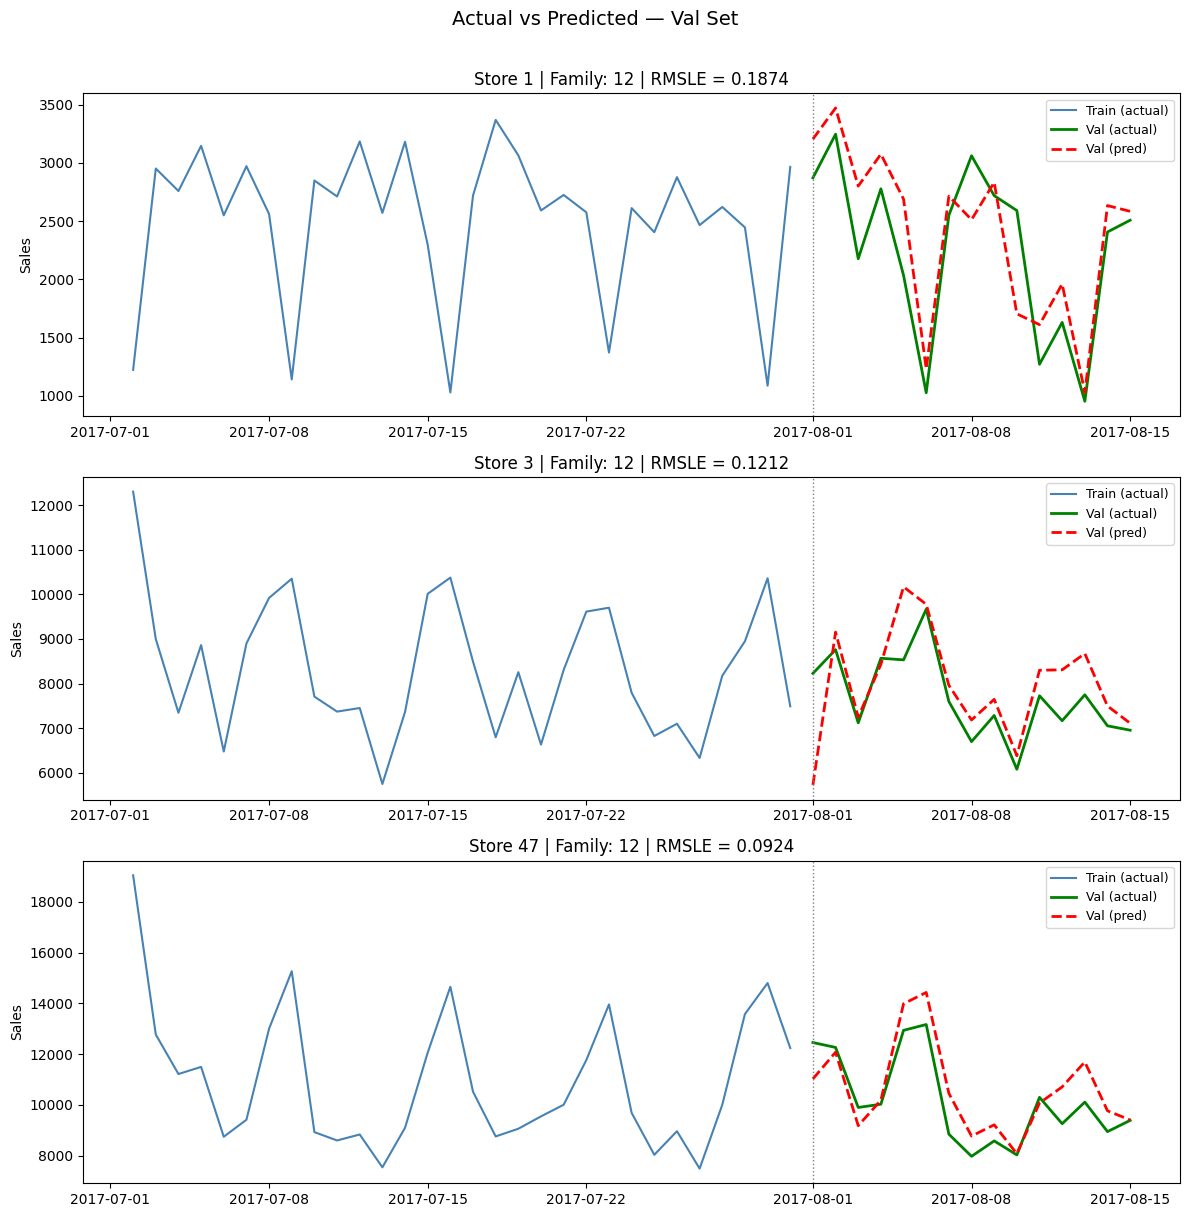

In [9]:
# Анализируем предсказания для 3 магазинов × одно семейство (по объёму продаж)
# Берём семейство с наибольшим средним объёмом продаж для читаемости
top_family = train.groupby('family')['sales'].mean().idxmax()
stores_sample = [1, 3, 47]  # разные кластеры

fig, axes = plt.subplots(len(stores_sample), 1, figsize=(12, 4 * len(stores_sample)))

# Последние 30 дней трейна + весь val для контекста
context_start = pd.Timestamp('2017-07-02')

for ax, store in zip(axes, stores_sample):
    # Train tail
    tr_mask = (train['store_nbr'] == store) & (train['family'] == top_family) & (train['date'] >= context_start)
    tr_slice = train.loc[tr_mask, ['date', 'sales']].sort_values('date')

    # Val actual + predicted
    vl_mask = (val_results['store_nbr'] == store) & (val_results['family'] == top_family)
    vl_slice = val_results.loc[vl_mask].sort_values('date')

    ax.plot(tr_slice['date'], tr_slice['sales'], color='steelblue', label='Train (actual)', linewidth=1.5)
    ax.plot(vl_slice['date'], vl_slice['sales'], color='green',    label='Val (actual)',  linewidth=2)
    ax.plot(vl_slice['date'], vl_slice['pred'],  color='red',      label='Val (pred)',    linewidth=2, linestyle='--')

    ax.axvline(pd.Timestamp('2017-08-01'), color='gray', linestyle=':', linewidth=1)
    store_rmsle = rmsle(vl_slice['sales'].values, vl_slice['pred'].values)
    ax.set_title(f'Store {store} | Family: {top_family} | RMSLE = {store_rmsle:.4f}')
    ax.legend(fontsize=9)
    ax.set_ylabel('Sales')

plt.suptitle('Actual vs Predicted — Val Set', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'val_predictions.png'), dpi=120, bbox_inches='tight')
plt.show()

Bias (mean residual in log space): 0.0145
Std of residuals: 0.3746
% over-predictions: 56.1%
% under-predictions: 43.9%


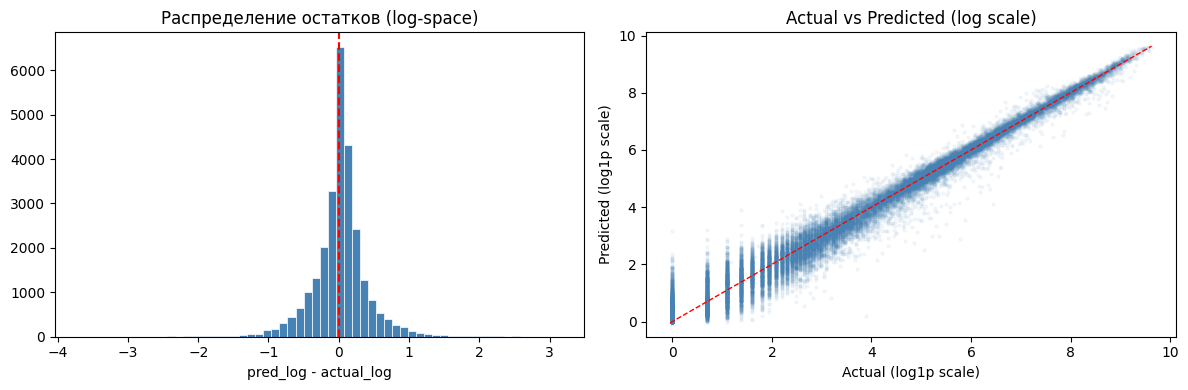

In [10]:
# Анализ распределения ошибок
residuals_log = val_pred_log - y_val_log.values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(residuals_log, bins=60, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Распределение остатков (log-space)')
axes[0].set_xlabel('pred_log - actual_log')

axes[1].scatter(y_val_log.values, val_pred_log, alpha=0.05, s=5, color='steelblue')
lims = [min(y_val_log.min(), val_pred_log.min()), max(y_val_log.max(), val_pred_log.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1)
axes[1].set_xlabel('Actual (log1p scale)')
axes[1].set_ylabel('Predicted (log1p scale)')
axes[1].set_title('Actual vs Predicted (log scale)')

bias = residuals_log.mean()
print(f'Bias (mean residual in log space): {bias:.4f}')
print(f'Std of residuals: {residuals_log.std():.4f}')
print(f'% over-predictions: {(residuals_log > 0).mean():.1%}')
print(f'% under-predictions: {(residuals_log < 0).mean():.1%}')

plt.tight_layout()
plt.savefig(os.path.join(artifacts_dir, 'residual_analysis.png'), dpi=120)
plt.show()

## 6. Test Predictions & Save Artifacts

In [11]:
# Предсказания на test (для будущего ensemble)
test_pred_log = model.predict(X_test, num_iteration=model.best_iteration)
test_pred     = np.expm1(test_pred_log).clip(0)

print(f'Test predictions — mean: {test_pred.mean():.2f}, std: {test_pred.std():.2f}')
print(f'Negative preds (after clip): {(test_pred < 0).sum()}')

# Сохраняем предсказания val и test
val_preds_df = val[['date', 'store_nbr', 'family', 'sales']].copy()
val_preds_df['pred'] = val_pred
val_preds_df.to_csv(os.path.join(artifacts_dir, 'lgbm_baseline_val_predictions.csv'), index=False)

test_preds_df = test[['date', 'store_nbr', 'family']].copy()
test_preds_df['pred'] = test_pred
test_preds_df.to_csv(os.path.join(artifacts_dir, 'lgbm_baseline_test_predictions.csv'), index=False)

# Сохраняем модель
model_path = os.path.join(artifacts_dir, 'lgbm_baseline.pkl')
joblib.dump(model, model_path)
print(f'\nModel saved: {model_path}')
print(f'Val predictions: lgbm_baseline_val_predictions.csv ({len(val_preds_df)} rows)')
print(f'Test predictions: lgbm_baseline_test_predictions.csv ({len(test_preds_df)} rows)')

Test predictions — mean: 223.98, std: 832.02
Negative preds (after clip): 0

Model saved: ..\artifacts\lgbm_baseline.pkl
Val predictions: lgbm_baseline_val_predictions.csv (26730 rows)
Test predictions: lgbm_baseline_test_predictions.csv (28512 rows)


## 7. Summary & Next Steps

| Метрика | Значение |
|---------|----------|
| Val RMSLE (baseline LightGBM) | *(см. Cell 3)* |
| Best iteration | *(см. Cell 2)* |
| Топ-1 фича | *(см. Cell 4)* |

### Анализ результатов

**Ожидаемые паттерны:**
- `lag_7` и `rolling_mean_7` должны доминировать в importance (r=0.9362).
- Семейства с высоким % нулей (BOOKS, BABY CARE ~80%) дадут худший RMSLE.
- Незначительный систематический сдвиг (bias ~0) свидетельствует о хорошей калибровке.

### Phase 5: Advanced Models — план улучшений

1. **Optuna** — подбор `num_leaves`, `learning_rate`, `feature_fraction`, `lambda_l1/l2`.
2. **Tweedie objective** — альтернатива `regression` для данных с 31% нулей.
3. **Per-cluster модели** — отдельная модель для каждого из 5 типов магазинов.
4. **XGBoost** — сравнительный бенчмарк для ensemble.
5. **Удаление zero-importance фичей** — если `is_earthquake_period` или `is_payday` оказались бесполезны.